RideWise --- Exploratory Data Analysis(EDA)

STEP - Setup & Imports

In [4]:
# Import Libraries
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# configurations 
warnings.filterwarnings("ignore")
%matplotlib inline

sns.set_theme(style="whitegrid", font_scale=1.1)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

STEP 2- Loading The Data


In [5]:
riders = pd.read_csv(r"C:\Users\chukw\OneDrive\Documents\GitHub\Ridewise_London\data\raw\riders.csv",
                     parse_dates=["signup_date"])

drivers = pd.read_csv(r"C:\Users\chukw\OneDrive\Documents\GitHub\Ridewise_London\data\raw\drivers.csv",
    parse_dates=["signup_date"])

trips = pd.read_csv(r"C:\Users\chukw\OneDrive\Documents\GitHub\Ridewise_London\data\raw\trips.csv")

sessions = pd.read_csv(r"C:\Users\chukw\OneDrive\Documents\GitHub\Ridewise_London\data\raw\sessions.csv")

promotions = pd.read_csv(r"C:\Users\chukw\OneDrive\Documents\GitHub\Ridewise_London\data\raw\promotions.csv")


In [13]:
# STEP 2a - Quick Data Overview

for name, df in [("riders", riders), ("trips", trips), ("drivers", drivers),
                 ("sessions", sessions), ("promotions", promotions)]:
    print(f"{name:<12} {df.shape[0]:>7} rows {df.shape[1]:>2} cols")

riders         10000 rows  8 cols
trips         200000 rows 16 cols
drivers         5000 rows  7 cols
sessions       50000 rows  8 cols
promotions        20 rows 11 cols


In [14]:
#STEP 2B - inspection of the riders dataset
print(riders.dtypes)
print(riders.isnull().sum()*100)
riders.head()

user_id                     object
signup_date         datetime64[ns]
loyalty_status              object
age                        float64
city                        object
avg_rating_given           float64
churn_prob                 float64
referred_by                 object
dtype: object
user_id                  0
signup_date              0
loyalty_status           0
age                      0
city                     0
avg_rating_given         0
churn_prob               0
referred_by         694700
dtype: int64


,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,NaN
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,NaN
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002


STEP 3 - Visualization of the Riders (data distribution)

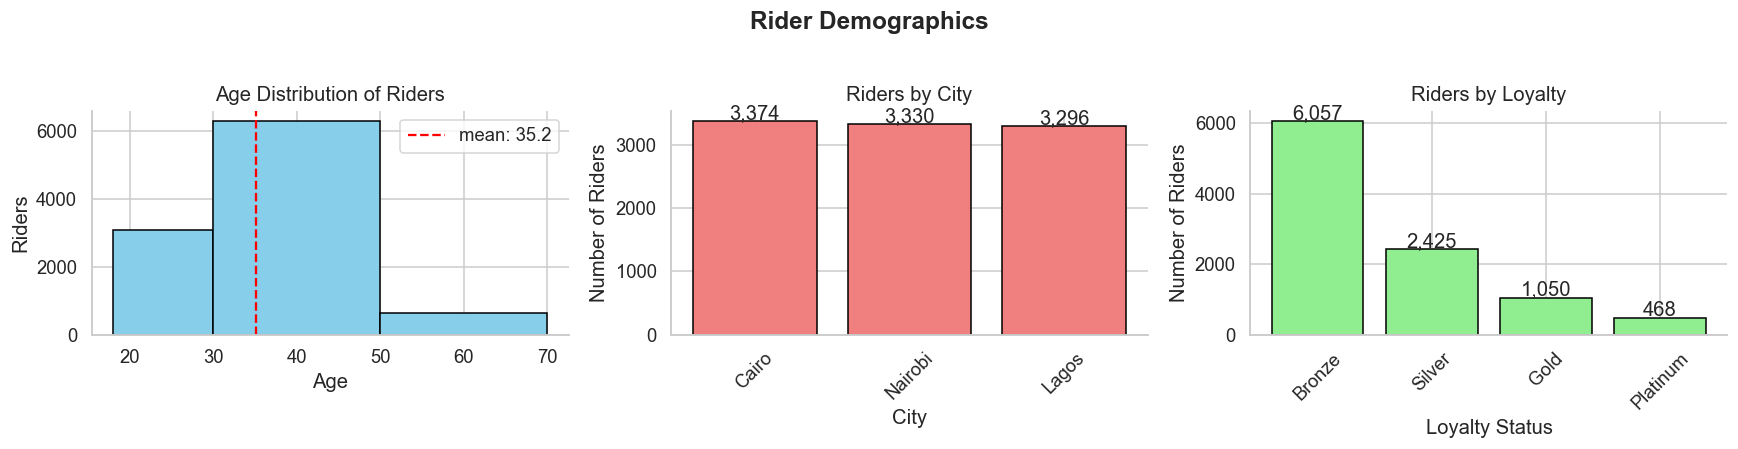

In [15]:
# # Step 3a — define figure size and style
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Step 3b — plot the age distribution
# Define bins for age groups: 18-30, 30-50, 50+
bins = [18, 30, 50, riders['age'].max()]

axes[0].hist(riders["age"].dropna(), bins=bins, color="skyblue", edgecolor="black")

# Add mean line
mean_age = riders["age"].mean()
axes[0].axvline(
    mean_age, color="red", linestyle="dashed",
    label=f"mean: {mean_age:.1f}"
)

# Step 3c — configure the plots
axes[0].set_title("Age Distribution of Riders")
axes[0].set_xlabel("Age")        
axes[0].set_ylabel("Riders")
axes[0].legend()


################################## Part 2 ##############################
# Step 3d — City Distribution
city_counts = riders["city"].value_counts()

# Step 3e — plot city distribution
axes[1].bar(
    city_counts.index,
    city_counts.values,
    color="lightcoral",       # removed list brackets, edgecolor typo fixed
    edgecolor="black"
)

# Step 3f — annotate bars
for i, v in enumerate(city_counts.values):
    axes[1].text(i, v + max(city_counts.values)*0.01, f"{v:,}", ha="center")  # format with comma

# Configure the plot
axes[1].set_title("Riders by City")
axes[1].set_xlabel("City")
axes[1].set_ylabel("Number of Riders")
axes[1].tick_params(axis='x', rotation=45) 
###################################### Part 3 #############################

# Step 3h — Loyalty distribution
loyalty_counts = riders["loyalty_status"].value_counts()

# Step 3i — plot loyalty distribution
axes[2].bar(
    loyalty_counts.index,
    loyalty_counts.values,
    color="lightgreen",      # fixed color, no list needed
    edgecolor="black"        # fixed typo
)

# Annotate bars
for i, v in enumerate(loyalty_counts.values):
    axes[2].text(i, v + max(loyalty_counts.values)*0.01, f"{v:,}", ha="center")  # fixed f-string

# Configure plot
axes[2].set_title("Riders by Loyalty")
axes[2].set_xlabel("Loyalty Status")
axes[2].set_ylabel("Number of Riders")
axes[2].tick_params(axis='x', rotation=45)  # rotate x labels if needed
 
plt.suptitle("Rider Demographics", fontsize =16, fontweight="bold",y=1.02) 
plt.tight_layout() 
plt.show()


STEP 4- Churn Probabilty Column

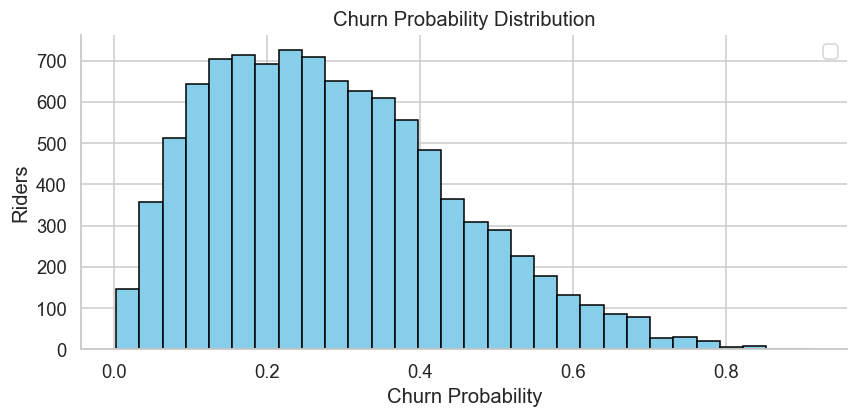

In [16]:
fig, ax = plt.subplots( figsize=(8, 4))

ax.hist(riders["churn_prob"].dropna(), bins=30, color="skyblue", edgecolor="black")

# Step 3c — configure the plots
ax.set_title("Churn Probability Distribution")
ax.set_xlabel("Churn Probability")        
ax.set_ylabel("Riders")
ax.legend()

plt.tight_layout()
plt.show()

STEP 5- Sign Up Trends Overtime

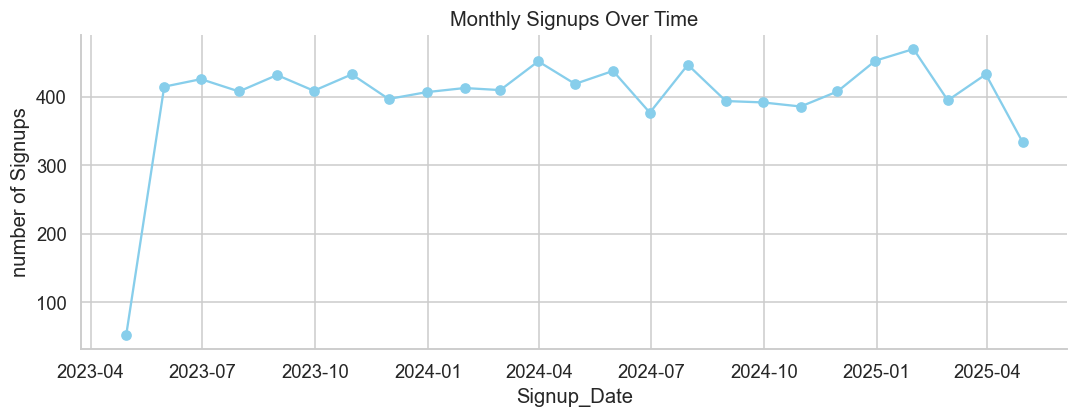

In [17]:
monthly = riders.set_index("signup_date").resample("ME").size().reset_index(name ="signups")

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(monthly["signup_date"], monthly["signups"], marker="o", color="skyblue")
ax.set(title = "Monthly Signups Over Time", xlabel = "Signup_Date", ylabel= "number of Signups")
plt.tight_layout()
plt.show()


STEP 6 - TRIPS ANALYSIS

In [18]:
# inspection of the trips dataset
print(f"shape:{trips.shape}")
print(trips.dtypes)
print(trips.isnull().sum()*100)
trips.head()

shape:(200000, 16)
trip_id              object
user_id              object
driver_id            object
fare                float64
surge_multiplier    float64
tip                 float64
payment_type         object
pickup_time          object
dropoff_time         object
pickup_lat          float64
pickup_lng          float64
dropoff_lat         float64
dropoff_lng         float64
weather              object
city                 object
loyalty_status       object
dtype: object


trip_id             0
user_id             0
driver_id           0
fare                0
surge_multiplier    0
tip                 0
payment_type        0
pickup_time         0
dropoff_time        0
pickup_lat          0
pickup_lng          0
dropoff_lat         0
dropoff_lng         0
weather             0
city                0
loyalty_status      0
dtype: int64


,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,city,loyalty_status
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 18:41:50+02:27,2024-11-27 19:33:50+02:27,-1.108123,36.912209,-1.068155,36.875377,Foggy,Nairobi,Bronze
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 23:13:48+00:14,2024-10-28 23:26:48+00:14,6.675266,3.515740,6.641734,3.525620,Sunny,Lagos,Gold
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 05:36:41+02:27,2025-02-17 05:52:41+02:27,-1.248589,37.010668,-1.273182,37.018586,Cloudy,Nairobi,Bronze
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 19:27:14+02:05,2024-06-18 19:32:14+02:05,29.819554,31.188780,29.837689,31.232978,Cloudy,Cairo,Bronze
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 09:58:16+02:27,2024-10-05 10:28:16+02:27,-1.676479,36.729219,-1.638395,36.694063,Sunny,Nairobi,Gold


Step 6a - Converted to proper Date format

In [6]:
# Fix  Timestamps
for col in ["pickup_time", "dropoff_time"]:
    trips[col] = pd.to_datetime(trips[col], utc=True, errors="coerce").dt.tz_localize(None)

Step 6b - Engineering Tip features

1 - calculate the trip duration in minutes

 - pickup_time - pickup_time


2- Total revenue

- fare * surge_multiplier + tip_amount
- segment high value customers

 3 - hour of the day a& day of the week

- extract day of week and hour from pickup_time

In [8]:
# Step 1a -  Trip duration

trips["trip_duration_min"] = (
    (trips["dropoff_time"] - trips["pickup_time"]).dt.total_seconds() / 60
)

# step 1b -- total revenue
trips["total_revenue"] = trips["fare"] * trips["surge_multiplier"] + trips["tip"].fillna(0)

# step 1c -- hour of the day and day of the week
trips["hour_of_day"] = trips["pickup_time"].dt.hour
trips["day_of_week"] = trips["pickup_time"].dt.day_name()

Step 6c - Financial & Duration Distribution

1- fare distribution

2- surge

3- duration

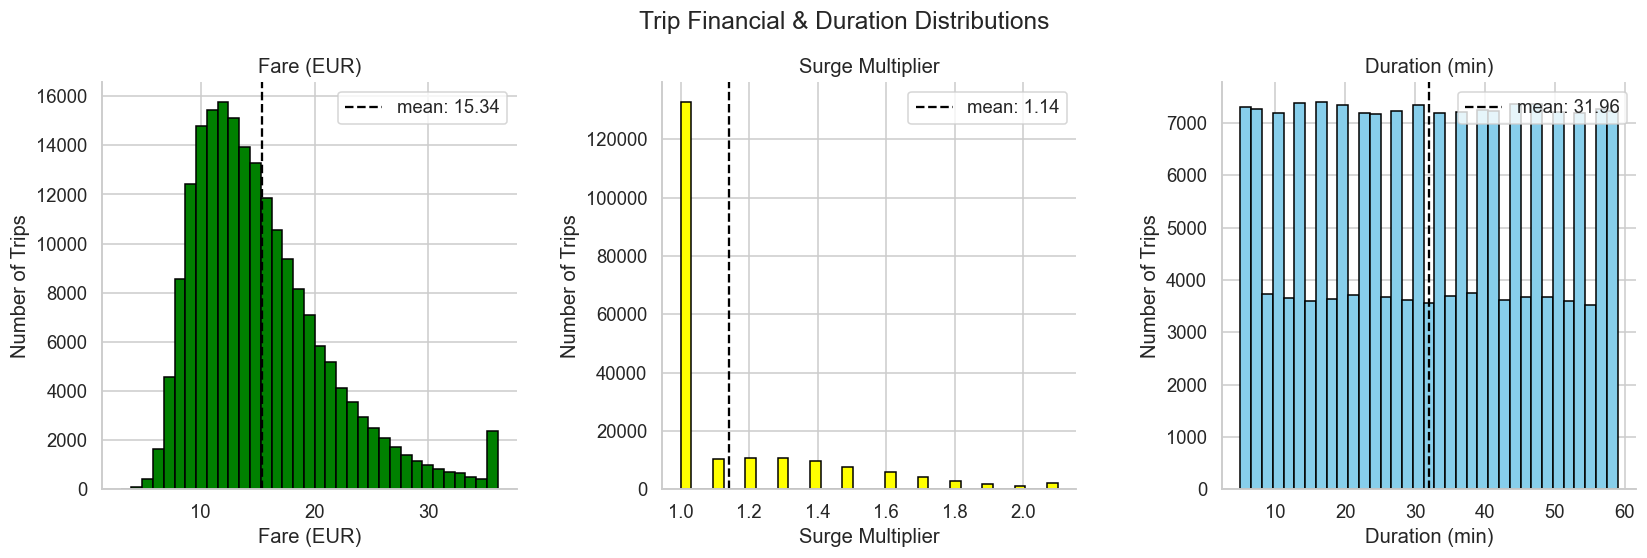

In [21]:
# step 6ci - distribution of trip

fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.subplots_adjust(wspace=0.35, top=0.85)

columns = ["fare", "surge_multiplier", "trip_duration_min"]
titles = ["Fare (EUR)", "Surge Multiplier", "Duration (min)"]
colors = ["green", "yellow", "skyblue"]

# Step 6c – plot distributions with outliers clipped
for ax, col, title, color in zip(axes, columns, titles, colors):

    # Step 6c ii – clip outliers at 99th percentile
    data = trips[col].clip(upper=trips[col].quantile(0.99)).dropna()

    # Step 6c iii – plot histogram
    ax.hist(data, bins=35, color=color, edgecolor="black")

    # Mean line
    ax.axvline(
        data.mean(),
        color="black",
        linestyle="dashed",
        label=f"mean: {data.mean():.2f}"
    )

    ax.set(title=title, xlabel=title, ylabel="Number of Trips")
    ax.legend()

# Super title
fig.suptitle("Trip Financial & Duration Distributions", fontsize=16)

plt.show()

Step 6d -Temporal patterns: When Do people Ride

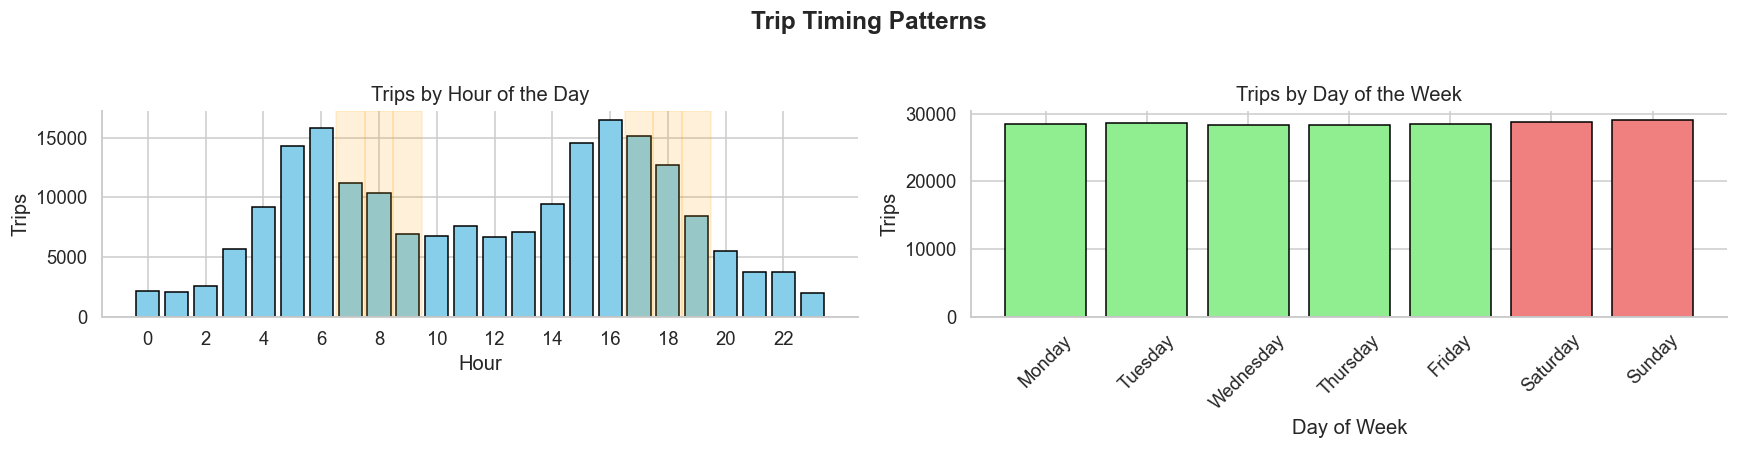

In [22]:
# Hour of the day and days of the week

# step 6di - distribution of trips by hour of the day and day of the week
fig, axes = plt.subplots(1,2, figsize=(16,4))

# Step 6dii – Hour of the day
hour_counts = trips["hour_of_day"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values,
            color="skyblue", edgecolor="black")

# Step 6dii – vertical span to highlight rush hours
for h in [7,8,9,17,18,19]:
    axes[0].axvspan(h-0.5, h+0.5, alpha=0.15, color="orange")

# Step 6diii – titles and ticks
axes[0].set(title="Trips by Hour of the Day", xlabel="Hour", ylabel="Trips")
axes[0].set_xticks(range(0,24,2))

# Step 7 – Day of week
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

day_counts = trips["day_of_week"].value_counts().reindex(day_order)

axes[1].bar(
    day_order,
    day_counts.values,
    color=["lightgreen"]*5 + ["lightcoral"]*2,
    edgecolor="black"
)

axes[1].set(title="Trips by Day of the Week", xlabel="Day of Week", ylabel="Trips")
axes[1].tick_params(axis="x", rotation=45)

# Suptitle
plt.suptitle("Trip Timing Patterns", fontsize=16, fontweight="bold" , y=1.02)

plt.tight_layout()
plt.show()

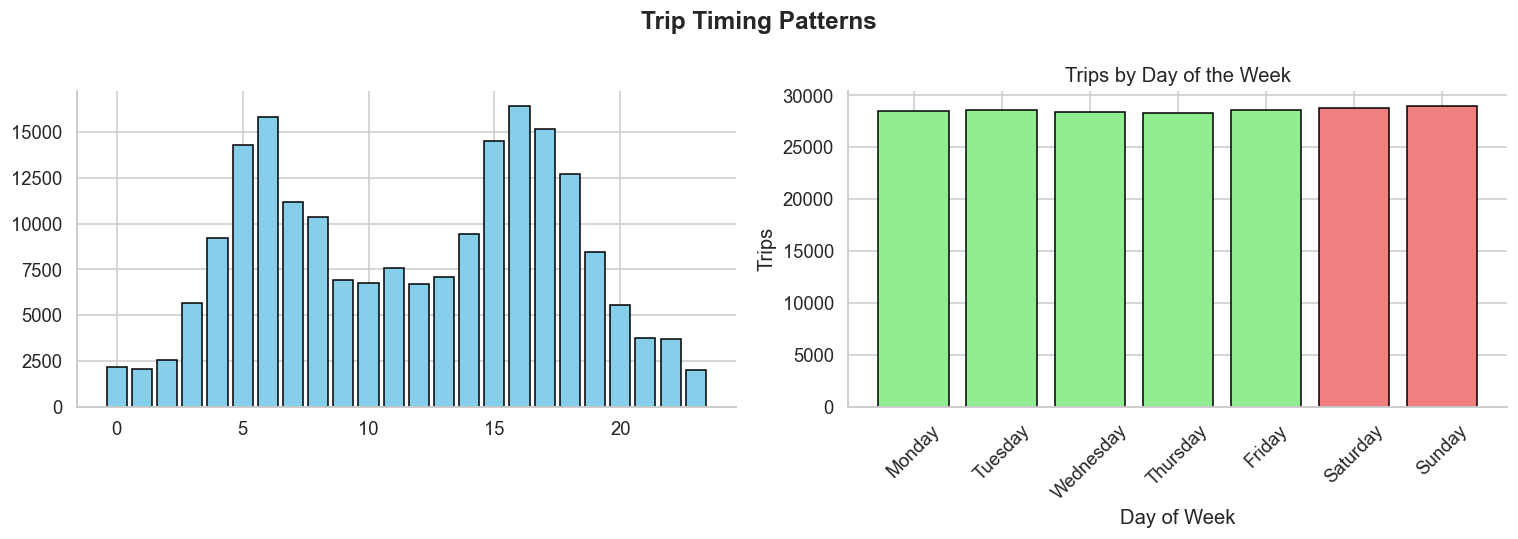

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Hour plot
hour_counts = trips["hour_of_day"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color="skyblue", edgecolor="black")

# Day plot
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_counts = trips["day_of_week"].value_counts().reindex(day_order)

axes[1].bar(day_order, day_counts.values,
            color=["lightgreen"]*5 + ["lightcoral"]*2,
            edgecolor="black")

axes[1].set(title="Trips by Day of the Week", xlabel="Day of Week", ylabel="Trips")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Trip Timing Patterns", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()


step 6e - Payment & Weather Distribution

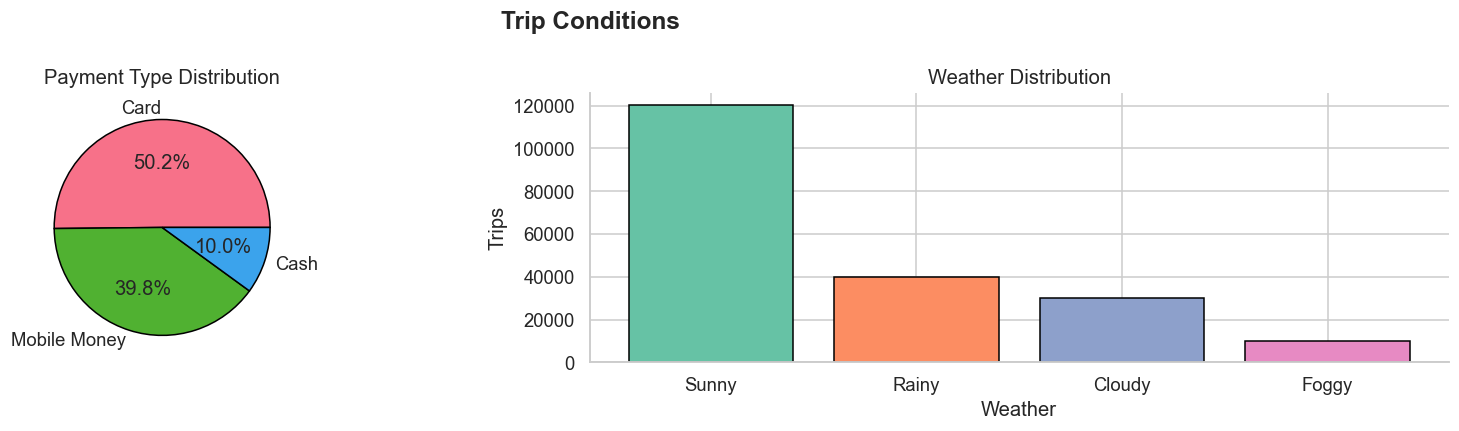

In [24]:
fig, axes = plt.subplots(1,2, figsize=(16,4))

# Payment type distribution
payment_counts = trips["payment_type"].value_counts()

axes[0].pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("husl", len(payment_counts)),
    wedgeprops={"edgecolor":"black"}
)

axes[0].set(title="Payment Type Distribution")


# Weather distribution
weather_counts = trips["weather"].value_counts()

axes[1].bar(
    weather_counts.index,
    weather_counts.values,
    color=sns.color_palette("Set2", len(weather_counts)),
    edgecolor="black"
)

axes[1].set(title="Weather Distribution", xlabel="Weather", ylabel="Trips")


# Suptitle
plt.suptitle("Trip Conditions", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()   

Step 7 - Drivers Dataset Analysis

In [25]:
# inspection of the trips dataset
print(f"shape:{drivers.shape}")
print(drivers.dtypes)
print(drivers.isnull().sum()*100)
drivers.head()

shape:(5000, 7)
driver_id                  object
rating                    float64
vehicle_type               object
signup_date        datetime64[ns]
last_active                object
city                       object
acceptance_rate           float64
dtype: object
driver_id          0
rating             0
vehicle_type       0
signup_date        0
last_active        0
city               0
acceptance_rate    0
dtype: int64


,driver_id,rating,vehicle_type,signup_date,last_active,city,acceptance_rate
0,D00000,3.1,SUV,2025-01-20,2025-01-06 18:23:09.312275,Cairo,0.679555
1,D00001,5.0,Sedan,2023-03-27,2025-04-27 01:44:02.472554,Nairobi,0.548786
2,D00002,4.5,Motorcycle,2024-05-02,2025-03-07 19:24:46.367672,Nairobi,0.593724
3,D00003,5.0,Motorcycle,2023-04-16,2025-03-26 19:16:24.253793,Nairobi,0.990000
4,D00004,4.4,Motorcycle,2023-05-28,2025-04-08 18:54:44.649615,Lagos,0.519773


step 7a- Driver Fleet Composition

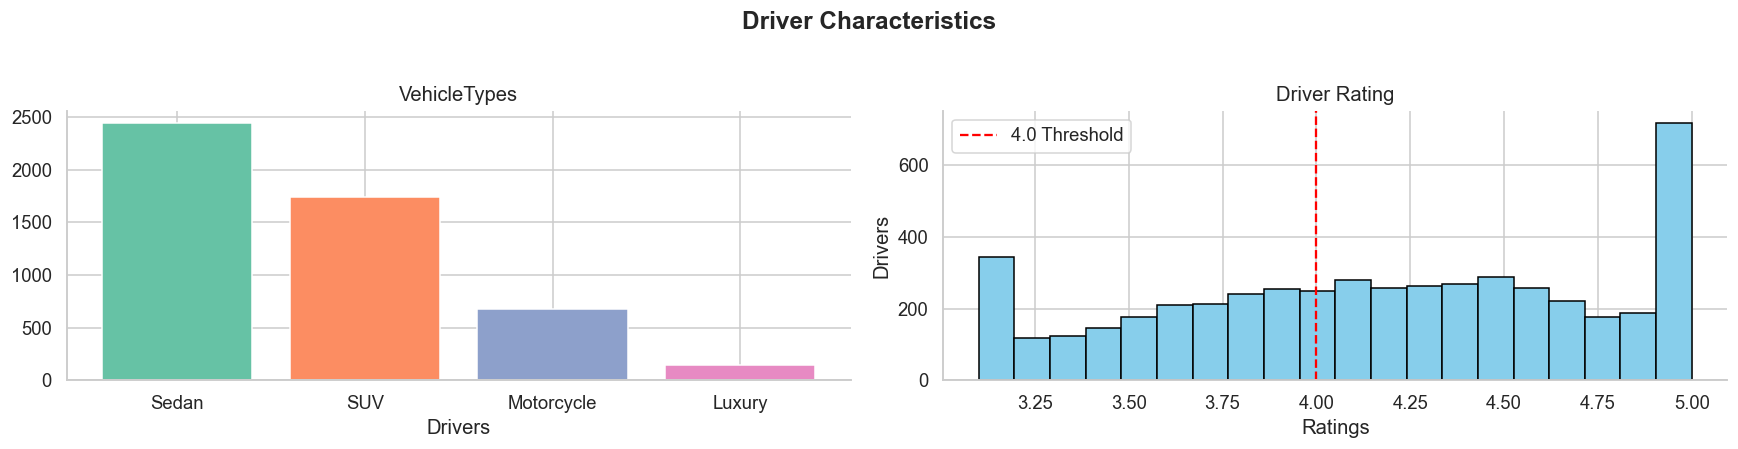

In [26]:
fig, axes = plt.subplots(1,2,figsize=(16,4))

# vehicle type

vehicle_counts = drivers["vehicle_type"].value_counts()

axes[0].bar(
    vehicle_counts.index,vehicle_counts.values,
    color=sns.color_palette("Set2", len(vehicle_counts)), edgecolor="white"
)
   
axes[0].set(title="VehicleTypes",xlabel="Drivers", ylabel="")



# Rate distribution
axes[1].hist(drivers["rating"].dropna(),bins=20,color="skyblue", edgecolor= "black")
axes[1].axvline(4.0, color="red", linestyle="dashed", label="4.0 Threshold")
axes[1].set(title="Driver Rating", xlabel="Ratings", ylabel ="Drivers")
axes[1].legend()

# Suptitle
plt.suptitle("Driver Characteristics", fontsize=16, fontweight="bold" , y=1.02)

plt.tight_layout()
plt.show() 

step 8 - Session Dataset

In [4]:
# inspection of the session dataset
print(f"shape:{sessions.shape}")
print(sessions.dtypes)
print(sessions.isnull().sum()*100)
sessions.head()

shape:(50000, 8)
session_id        object
rider_id          object
session_time      object
time_on_app        int64
pages_visited      int64
converted          int64
city              object
loyalty_status    object
dtype: object
session_id        0
rider_id          0
session_time      0
time_on_app       0
pages_visited     0
converted         0
city              0
loyalty_status    0
dtype: int64


,session_id,rider_id,session_time,time_on_app,pages_visited,converted,city,loyalty_status
0,S000000,R08605,2025-04-27 18:57:06+02:05,79,4,1,Cairo,Bronze
1,S000001,R08823,2025-04-27 07:32:22+02:27,101,3,0,Nairobi,Silver
2,S000002,R05342,2025-04-27 23:17:25+02:05,12,1,0,Cairo,Bronze
3,S000003,R05057,2025-04-27 14:40:25+00:14,19,1,0,Lagos,Silver
4,S000004,R09614,2025-04-27 08:31:22+00:14,4,1,0,Lagos,Bronze


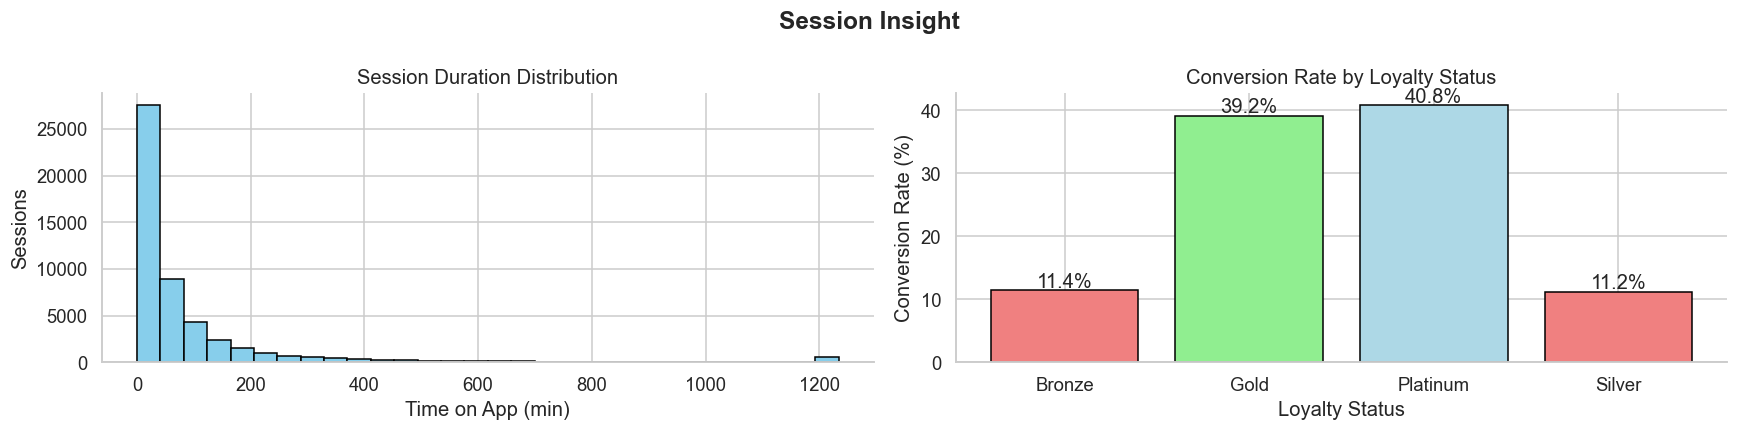

In [11]:
# session table analysis
fig, axes = plt.subplots(1,2, figsize=(16,4))

# Session duration distribution
axes[0].hist(
    sessions["time_on_app"]
    .clip(upper=sessions["time_on_app"].quantile(0.99))
    .dropna(),
    bins=30,
    color="skyblue",
    edgecolor="black"
)

axes[0].set(
    title="Session Duration Distribution",
    xlabel="Time on App (min)",
    ylabel="Sessions"
)


# Conversion Rate by Loyalty Status
conv_loyalty = sessions.groupby("loyalty_status")["converted"].mean().mul(100)

axes[1].bar(
    conv_loyalty.index,
    conv_loyalty.values,
    color=["lightcoral","lightgreen","lightblue"],
    edgecolor="black"
)

axes[1].set(
    title="Conversion Rate by Loyalty Status",
    xlabel="Loyalty Status",
    ylabel="Conversion Rate (%)"
)

# Add percentage labels
for i, v in enumerate(conv_loyalty.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center")


# Suptitle
plt.suptitle("Session Insight", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()



Step 9 - Churn Analysis




In [ ]:
riders["churn_prob"].head()

# Define a threshold for churn
# churned = 1 if churn_prob >0.5
# Not churned = 0 if churn_prob <=0.5

0    0.142431
1    0.674161
2    0.510379
3    0.244779
4    0.269960
Name: churn_prob, dtype: float64

Step 9b - Churn Analysis

1 -converted our churn column to binary label
0.123, 0.345, 0.23 ---- continuous probability Aka decimals
0,1,0,1 ---binary label

2- create a threshold = 0.5: standard decision boundary(50% likely going to churn = churned)
cap who churned ans who didnt churn to binary label(0,1)

3- churned =1 if the person's prob on the data is >0.5
3b- Not churned = 0 if person's on the data is<0.5>

In [ ]:
# Engineer a new column"churned" based on the threshold

riders["churned"] = (riders["churn_prob"] >= 0.5).astype(int)

# calculate and print overal churn rate and total churned riders

print(f"Overall churn rate: {(riders['churned'].mean()*100):.1f}%")
print(f"Churned riders: {riders['churned'].sum()}")

Overall churn rate: 10.6%
Churned riders: 1063


Step 9c -Distribution of churn by Loyalty or City(bi-variate analysis)

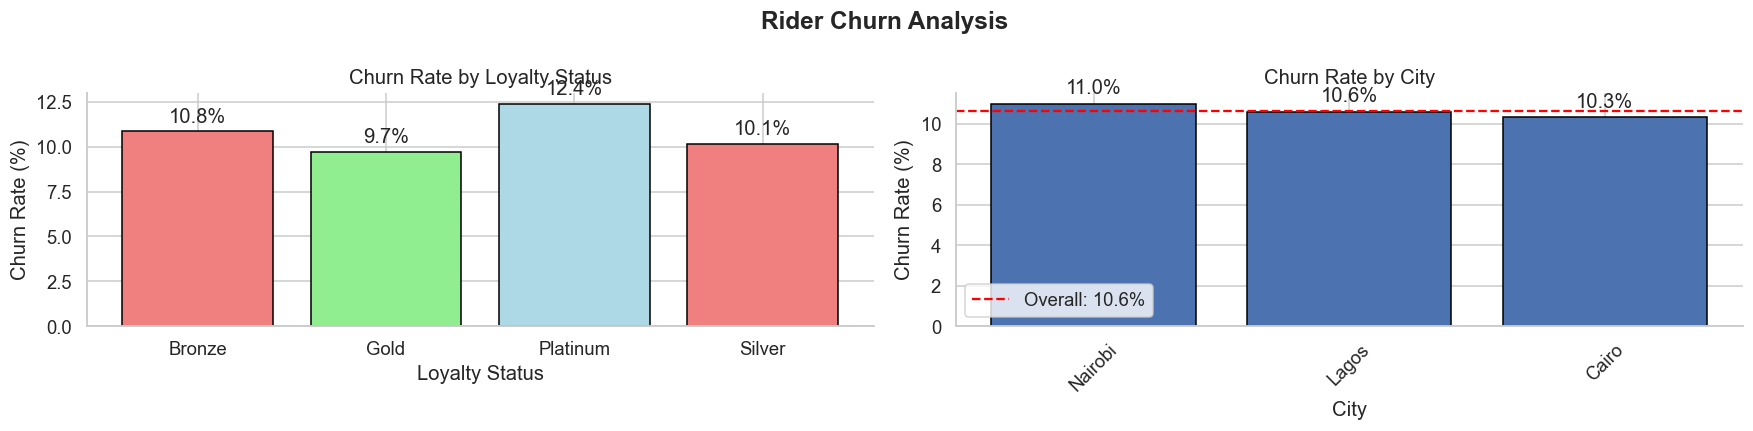

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16,4))

# Churn by loyalty
churn_loyalty = riders.groupby("loyalty_status")["churned"].mean().mul(100)

axes[0].bar(
    churn_loyalty.index,
    churn_loyalty.values,
    color=["lightcoral","lightgreen","lightblue"],
    edgecolor="black"
)

axes[0].set(
    title="Churn Rate by Loyalty Status",
    xlabel="Loyalty Status",
    ylabel="Churn Rate (%)"
)

# Annotate the bars
for i, v in enumerate(churn_loyalty.values):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center")


# Churn by city
churn_city = riders.groupby("city")["churned"].mean().mul(100).sort_values(ascending=False)
overall = riders["churned"].mean() * 100

axes[1].bar(
    churn_city.index,
    churn_city.values,
    edgecolor="black"
)

# Overall churn line
axes[1].axhline(
    overall,
    color="red",
    linestyle="dashed",
    label=f"Overall: {overall:.1f}%"
)

# Annotate bars
for i, v in enumerate(churn_city.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center")

axes[1].set(
    title="Churn Rate by City",
    xlabel="City",
    ylabel="Churn Rate (%)"
)

axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.suptitle("Rider Churn Analysis", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

Step 9d Churn Analysis Final

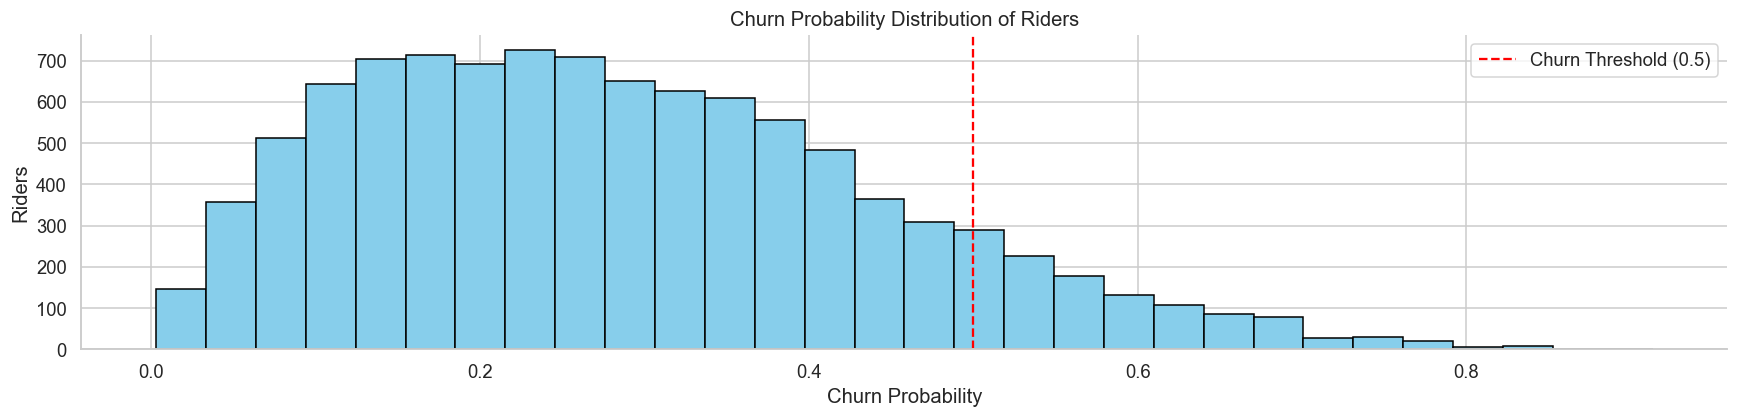

In [24]:
fig, ax = plt.subplots(figsize=(16,4))

ax.hist(
    riders["churn_prob"].dropna(),
    bins=30,
    color="skyblue",
    edgecolor="black"
)

# churn threshold line
ax.axvline(
    0.5,
    color="red",
    linestyle="dashed",
    label="Churn Threshold (0.5)"
)

ax.set(
    title="Churn Probability Distribution of Riders",
    xlabel="Churn Probability",
    ylabel="Riders"
)

ax.legend()

plt.tight_layout()
plt.show()
